In [1]:
# Session 15
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Columns in dataset:
['formula', 'T', 'Cp']


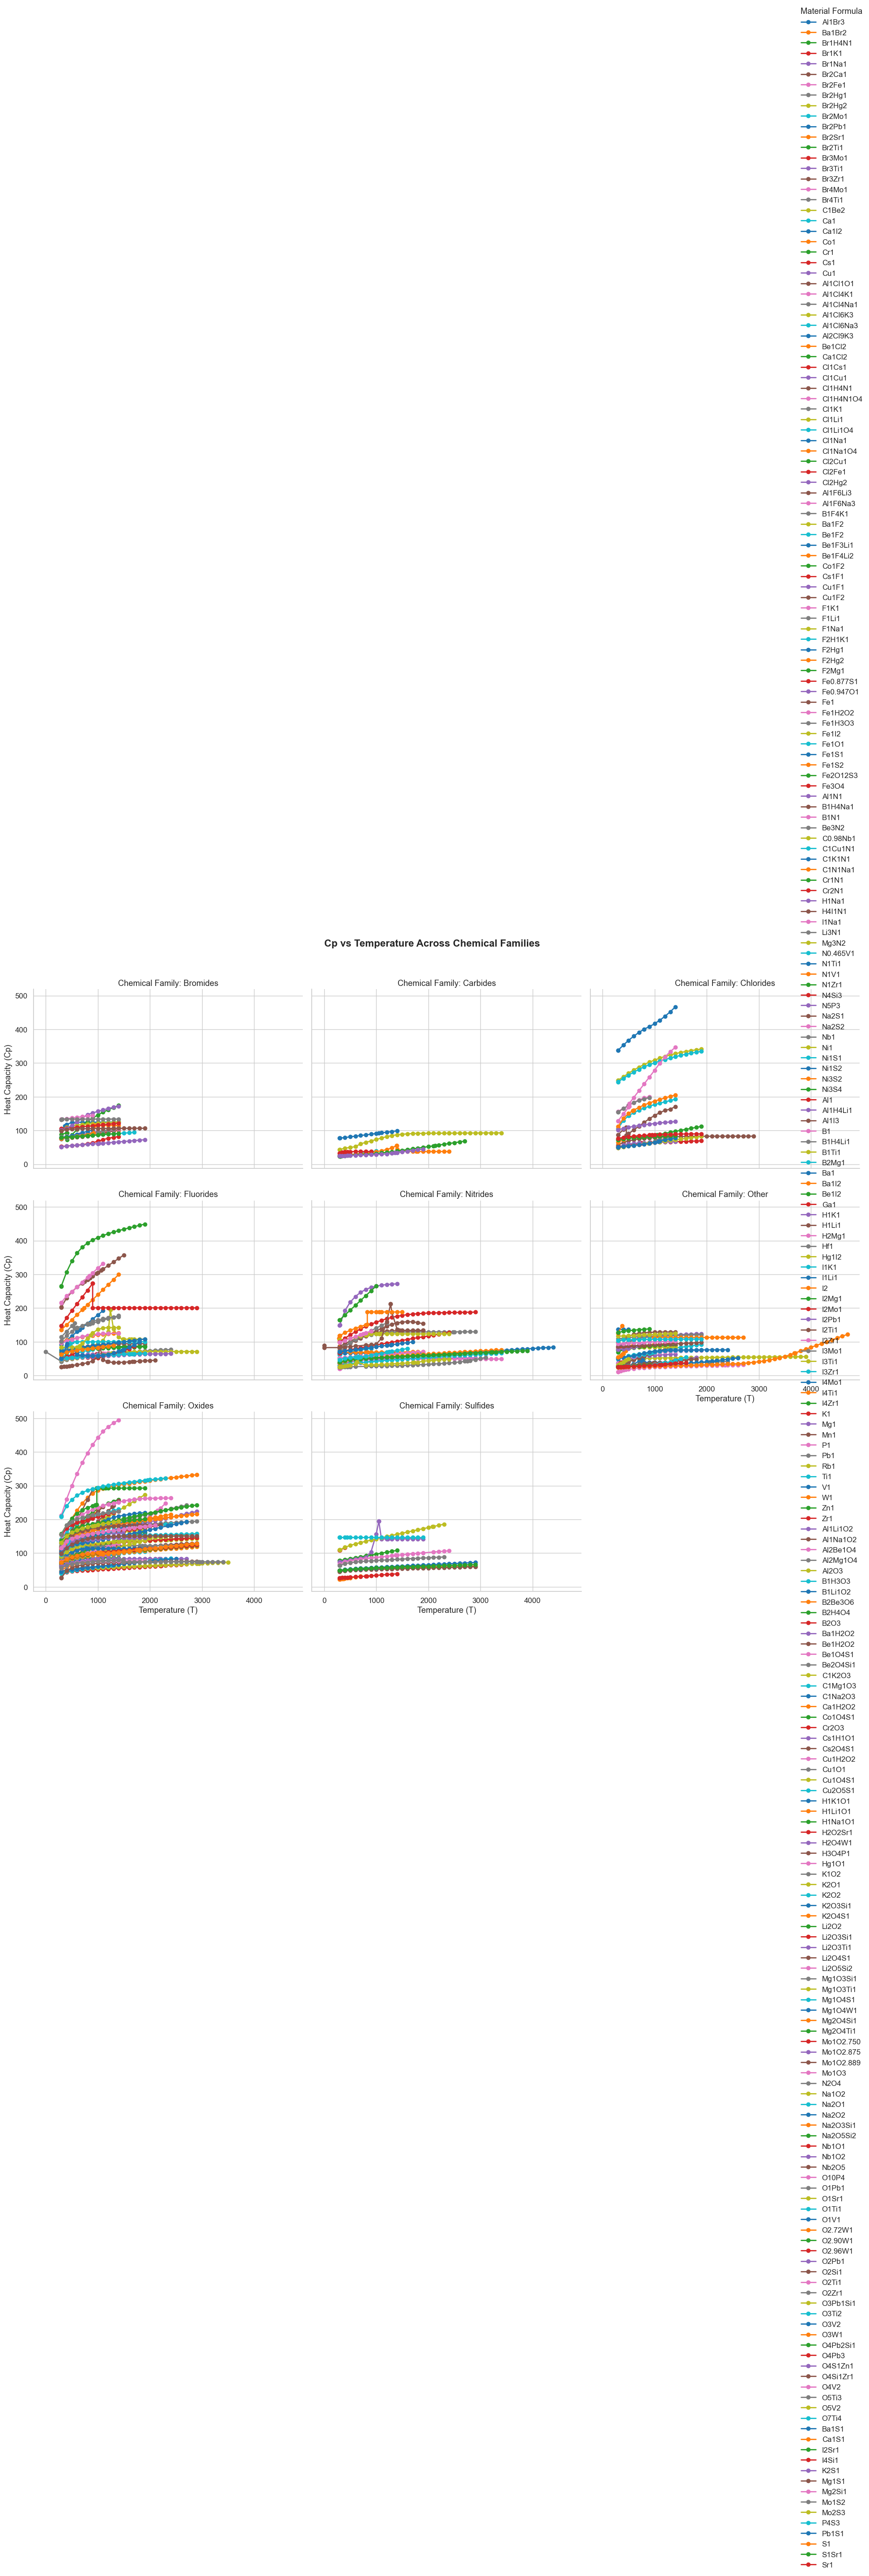

In [6]:
# --------------------------------------------------
# 1. Load the cleaned dataset
# --------------------------------------------------

df = pd.read_csv("cleaned_cp_dataset.csv")

# --------------------------------------------------
# 2. Clean column names
# --------------------------------------------------
df.columns = df.columns.str.strip()

print("Columns in dataset:")
print(df.columns.tolist())
# --------------------------------------------------
# 3. Make sure required columns exist
# --------------------------------------------------
required_columns = ["formula", "T", "Cp"]

for column in required_columns:
    if column not in df.columns:
        raise ValueError(
            f"Required column '{column}' is missing. "
            f"Available columns are: {df.columns.tolist()}"
        )
# --------------------------------------------------
# 4. Create chemical family column if it doesn't exist
# --------------------------------------------------

if "family" not in df.columns:

    def classify_family(formula):
        formula = str(formula)

        if "Cl" in formula:
            return "Chlorides"

        elif "Br" in formula:
            return "Bromides"

        elif "F" in formula:
            return "Fluorides"

        elif "O" in formula:
            return "Oxides"

        elif "N" in formula:
            return "Nitrides"

        elif "S" in formula:
            return "Sulfides"

        elif "C" in formula:
            return "Carbides"

        else:
            return "Other"

    df["family"] = df["formula"].apply(classify_family)

# --------------------------------------------------
# 5. Remove missing values
# --------------------------------------------------
df = df.dropna(subset=["T", "Cp", "formula", "family"])
# --------------------------------------------------
# 6. Sort data by family, formula and temperature
# --------------------------------------------------

df = df.sort_values(
    by=["family", "formula", "T"]
)
# --------------------------------------------------
# 7. Set Seaborn style
# --------------------------------------------------
sns.set_theme(
    style="whitegrid",
    font_scale=1.1
)
# --------------------------------------------------
# 8. Create FacetGrid
# --------------------------------------------------
g = sns.FacetGrid(
    df,
    col="family",
    hue="formula",
    col_wrap=3,
    height=5,
    aspect=1.2,
    palette="tab10"
)
# --------------------------------------------------
# 9. Plot Cp vs T
# --------------------------------------------------

g.map(
    plt.plot,
    "T",
    "Cp",
    marker="o",
    linewidth=2
)
# --------------------------------------------------
# 10. Add axis labels
# --------------------------------------------------

g.set_axis_labels(
    "Temperature (T)",
    "Heat Capacity (Cp)"
)
# --------------------------------------------------
# 11. Add titles
# --------------------------------------------------

g.set_titles(
    "Chemical Family: {col_name}"
)
# --------------------------------------------------
# 12. Add legend
# --------------------------------------------------
g.add_legend(
    title="Material Formula"
)
# --------------------------------------------------
# 13. Add overall title
# --------------------------------------------------
g.fig.suptitle(
    "Cp vs Temperature Across Chemical Families",
    fontsize=16,
    fontweight="bold",
    y=1.02
)
# --------------------------------------------------
# 14. Improve layout
# --------------------------------------------------
plt.tight_layout()
# --------------------------------------------------
# 15. Display plot
# --------------------------------------------------
plt.show()